## Install Unsloth


In [3]:
#   Install Unsloth library
! pip install unsloth --upgrade --no-cache-dir

# Install Flash Attention 2 for softcapping support
import torch
if torch.cuda.get_device_capability()[0] >= 8:
    !pip install --no-deps packaging ninja einops "flash-attn>=2.6.3"

## Login to HF

In [5]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

## Finetuning Gemma 3 using Unsloth library

### Initializing Gemma 3 model

Load the Gemma 3 1B model using the `FastModel` class

In [6]:
from unsloth import FastModel
import torch

max_seq_length = 2048

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # Use 4bit quantization to reduce memory usage.
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


model.safetensors:   0%|          | 0.00/1.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

Add LoRA adapters

In [7]:
model = FastModel.get_peft_model(
    model,
    r = 128, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 128,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

### Load dataset

Load `train.jsonl` file

In [8]:
from datasets import load_dataset

dataset = load_dataset("llm-lab/TuringQ", split= "train")

README.md:   0%|          | 0.00/3.06k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.15M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4006 [00:00<?, ? examples/s]

In [9]:
for i in dataset[0]:
  print(f"{i}: {dataset[0][i]}")

Question: Show that the following is not regular. L = {ww^R: w ∈ {a, b}*}
Answer: L = {ww^R: w ∈ {a, b}*}. L is the set of all strings whose first half is equal to the reverse of the second half. All strings in L must have even length. If L is regular, then the pumping lemma tells us that ∃ N ≥ 1, such that ∀ strings w ∈ L, where |w| ≥ N, ∃ x, y, z, such that w = xyz, |xy| ≤ N, y ≠ ε, and ∀ q ≥ 0, xy^qz is in L. We must pick a string w ∈ L and show that it does not meet these requirements. First, don’t get confused by the fact that we must pick a string w, yet we are looking for strings of the form ww^R. These are two independent uses of the variable name w. It just happens that the problem statement uses the same variable name that the pumping lemma does. If it helps, restate the problem as L = {ss^R: s ∈ {a, b}*}. We need to choose a “long” w, i.e., one whose length is greater than N. But it may be easier if we choose one that is even longer than that. Remember that the fact that |xy

## Data Prep

Use `get_chat_template` function to get the correct chat template.

In [10]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma3",
)

Use `convert_to_chatml` to try converting `dataset` to the correct format for finetuning

In [11]:
def convert_to_chatml(example):
  return {
      "conversations": [
          {"role": "user", "content": example["Question"]},
          {"role": "assistant", "content": example["Answer"]},

      ]
  }

dataset = dataset.map(
    convert_to_chatml
)

Map:   0%|          | 0/4006 [00:00<?, ? examples/s]

In [12]:
dataset[0]

{'Question': 'Show that the following is not regular. L = {ww^R: w ∈ {a, b}*}',
 'Answer': 'L = {ww^R: w ∈ {a, b}*}. L is the set of all strings whose first half is equal to the reverse of the second half. All strings in L must have even length. If L is regular, then the pumping lemma tells us that ∃ N ≥ 1, such that ∀ strings w ∈ L, where |w| ≥ N, ∃ x, y, z, such that w = xyz, |xy| ≤ N, y ≠ ε, and ∀ q ≥ 0, xy^qz is in L. We must pick a string w ∈ L and show that it does not meet these requirements. First, don’t get confused by the fact that we must pick a string w, yet we are looking for strings of the form ww^R. These are two independent uses of the variable name w. It just happens that the problem statement uses the same variable name that the pumping lemma does. If it helps, restate the problem as L = {ss^R: s ∈ {a, b}*}. We need to choose a “long” w, i.e., one whose length is greater than N. But it may be easier if we choose one that is even longer than that. Remember that the fac

Apply chat template for `Gemma3` onto the conversations, and save it to `text`

In [13]:
def formatting_prompts_func(examples):
  convos = examples["conversations"]
  texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos]
  return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/4006 [00:00<?, ? examples/s]

In [14]:
dataset[0]["text"]

'<start_of_turn>user\nShow that the following is not regular. L = {ww^R: w ∈ {a, b}*}<end_of_turn>\n<start_of_turn>model\nL = {ww^R: w ∈ {a, b}*}. L is the set of all strings whose first half is equal to the reverse of the second half. All strings in L must have even length. If L is regular, then the pumping lemma tells us that ∃ N ≥ 1, such that ∀ strings w ∈ L, where |w| ≥ N, ∃ x, y, z, such that w = xyz, |xy| ≤ N, y ≠ ε, and ∀ q ≥ 0, xy^qz is in L. We must pick a string w ∈ L and show that it does not meet these requirements. First, don’t get confused by the fact that we must pick a string w, yet we are looking for strings of the form ww^R. These are two independent uses of the variable name w. It just happens that the problem statement uses the same variable name that the pumping lemma does. If it helps, restate the problem as L = {ss^R: s ∈ {a, b}*}. We need to choose a “long” w, i.e., one whose length is greater than N. But it may be easier if we choose one that is even longer th

## Training

In [15]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 1, # Use GA to mimic batch size!
        warmup_steps = 5,
        num_train_epochs = 3, # Set this for 1 full training run.
        max_steps = -1,
        learning_rate = 2e-5, # Reduce to 2e-5 for long training runs
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4006 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Use `train_on_completions` method to only train on teh assistant outputs and ignore the loss on the user's inputs.

This helps increase accuracy of finetunes!

In [16]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Map (num_proc=6):   0%|          | 0/4006 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/4006 [00:00<?, ? examples/s]

Verify masking instruction part is done

In [17]:
tokenizer.decode(trainer.train_dataset[0]["input_ids"])

'<bos><start_of_turn>user\nShow that the following is not regular. L = {ww^R: w ∈ {a, b}*}<end_of_turn>\n<start_of_turn>model\nL = {ww^R: w ∈ {a, b}*}. L is the set of all strings whose first half is equal to the reverse of the second half. All strings in L must have even length. If L is regular, then the pumping lemma tells us that ∃ N ≥ 1, such that ∀ strings w ∈ L, where |w| ≥ N, ∃ x, y, z, such that w = xyz, |xy| ≤ N, y ≠ ε, and ∀ q ≥ 0, xy^qz is in L. We must pick a string w ∈ L and show that it does not meet these requirements. First, don’t get confused by the fact that we must pick a string w, yet we are looking for strings of the form ww^R. These are two independent uses of the variable name w. It just happens that the problem statement uses the same variable name that the pumping lemma does. If it helps, restate the problem as L = {ss^R: s ∈ {a, b}*}. We need to choose a “long” w, i.e., one whose length is greater than N. But it may be easier if we choose one that is even long

Print the masked example, a token `x` with `x = -100` means it's ignored during training

In [18]:
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, " ")

"                                                         False. Consider L = a^nb^n. L' = {w ∈ {a, b}* : either some b comes before some a or there is an unequal number of a's and b's.}. Clearly this language is not regular since we can't count the a's and b's.<end_of_turn>\n"

Start training

In [19]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,006 | Num Epochs = 3 | Total steps = 3,006
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 104,366,080 of 1,104,252,032 (9.45% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,2.774831
20,2.173268
30,2.125447
40,2.029540
50,2.131515
60,1.993581
70,1.961006
80,1.857624
90,2.180048
100,1.974117


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-500.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-1000.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1500/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-1500.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-2000/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-2000.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-2500/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-2500.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-3000/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-3000.
U

Plot the loss curve

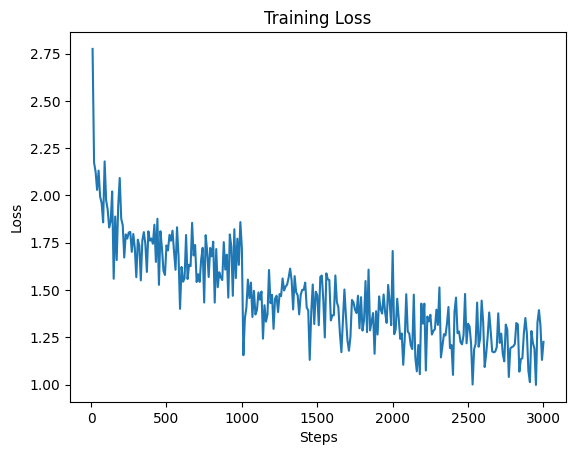

In [20]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

losses = [x["loss"] for x in logs if "loss" in x]
steps = [x["step"] for x in logs if "loss" in x]

plt.plot(steps, losses)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Although there were significant fluctuations, the loss curve shows a decreasing trend overall, indicating the model did learn some knowledge

## Save the finetuned model

### Save the final model as LoRA adapters

Use `save_pretrained`

In [21]:
model.save_pretrained("gemma_3_lora")
tokenizer.save_pretrained("gemma_3_lora")

Unsloth: Restored added_tokens_decoder metadata in gemma_3_lora/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_3_lora.


('gemma_3_lora/tokenizer_config.json',
 'gemma_3_lora/chat_template.jinja',
 'gemma_3_lora/tokenizer.json')

## Save the final model as GGUF

In [22]:
model.save_pretrained_gguf(
    "gemma_3_finetune",
    tokenizer,
    quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
)

Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### Your chat template has a BOS token. We shall remove it temporarily.


Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/902 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in gemma_3_finetune/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in gemma_3_finetune.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:42<00:00, 42.60s/it]


Unsloth: Merge process complete. Saved to `/content/gemma_3_finetune`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b9724 (llama-b9724-bin-ubuntu-x64.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma_3_finetune_gguf/gemma-3-1b-it.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q8_0. This might take 10 minutes...


Unsloth: ##### The current model auto adds a BOS token.
Unsloth: ##### We removed it in GGUF's chat template for you.


Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma_3_finetune_gguf/gemma-3-1b-it.Q8_0.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model gemma_3_finetune_gguf/gemma-3-1b-it.Q8_0.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to gemma_3_finetune_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f gemma_3_finetune_gguf/Modelfile


{'save_directory': 'gemma_3_finetune',
 'gguf_directory': 'gemma_3_finetune_gguf',
 'gguf_files': ['gemma_3_finetune_gguf/gemma-3-1b-it.Q8_0.gguf'],
 'modelfile_location': 'gemma_3_finetune_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': True}

Download model files to local machine

In [23]:
# 1. Zip the folder (Replace 'my_folder' with your actual folder name)
!zip -r /content/gemma_3_TuringQ_LoRA.zip /content/gemma_3_lora
!zip -r /content/gemma_3_TuringQ_Finetune.zip /content/gemma_3_finetune
!zip -r /content/gemma_3_TuringQ_Finetune_GGUF.zip /content/gemma_3_finetune_gguf/

# 2. Download the zip file to your local computer
from google.colab import files

files.download

  adding: content/gemma_3_lora/ (stored 0%)
  adding: content/gemma_3_lora/chat_template.jinja (deflated 70%)
  adding: content/gemma_3_lora/tokenizer_config.json (deflated 97%)
  adding: content/gemma_3_lora/README.md (deflated 65%)
  adding: content/gemma_3_lora/tokenizer.model (deflated 52%)
  adding: content/gemma_3_lora/tokenizer.json (deflated 83%)
  adding: content/gemma_3_lora/adapter_config.json (deflated 59%)
  adding: content/gemma_3_lora/adapter_model.safetensors (deflated 8%)
  adding: content/gemma_3_finetune/ (stored 0%)
  adding: content/gemma_3_finetune/.cache/ (stored 0%)
  adding: content/gemma_3_finetune/.cache/huggingface/ (stored 0%)
  adding: content/gemma_3_finetune/.cache/huggingface/.gitignore (stored 0%)
  adding: content/gemma_3_finetune/.cache/huggingface/CACHEDIR.TAG (deflated 24%)
  adding: content/gemma_3_finetune/.cache/huggingface/download/ (stored 0%)
  adding: content/gemma_3_finetune/.cache/huggingface/download/model.safetensors.metadata (deflated 2

<function google.colab.files.download(filename)>